# Module 1: 基础设置与依赖库 (Setup)

In [17]:
# Cell 1: Imports
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import signal
from scipy.signal import find_peaks
from scipy.stats import skew, kurtosis
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
import warnings
warnings.filterwarnings('ignore')
import joblib
# 绘图风格设置
plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)

print("✅ Libraries Imported Successfully")

✅ Libraries Imported Successfully


In [2]:
# ==== 全局配置 ====
DATA_PATH = "data/EOG_data"  # 请确保您的数据在这个目录下
CLASSES = ["Rest", "Up", "Down", "Left", "Right", "Blink"]
TARGET_FS = 50   # 目标采样率 50Hz
WINDOW_SIZE = 50 # 窗口大小 (1秒)
STEP_SIZE = 10   # (仅用于Rest的滑动步长)

# Module 2: 数据载入 (Data Loading)

In [3]:
SAMPLING_RATE = 50
# ================= 2. 深度数据载入 =================
def load_raw_data():
    raw_data, labels, filenames = [], [], []
    subjects = [s for s in os.listdir(DATA_PATH) if os.path.isdir(os.path.join(DATA_PATH, s))]
    print(f"🚀 Scanning Subjects: {subjects}")

    # 用于最后汇总打印
    file_summary = {s: {c: [] for c in CLASSES} for s in subjects}

    for subject in subjects:
        sub_path = os.path.join(DATA_PATH, subject)
        for class_name in CLASSES:
            class_folder = os.path.join(sub_path, class_name)
            if not os.path.exists(class_folder): continue
            csv_files = [f for f in os.listdir(class_folder) if f.endswith(".csv")]
            
            for file in csv_files:
                file_path = os.path.join(class_folder, file)
                try:
                    df = pd.read_csv(file_path, header=None)
                    if isinstance(df.iloc[0, 0], str): df = pd.read_csv(file_path, header=0)
                    df = df.iloc[:, 1:3] # 只取两列
                    df.columns = ['EOG_H', 'EOG_V']
                    df = df.apply(pd.to_numeric, errors='coerce').dropna()
                    
                    if len(df) >= SAMPLING_RATE:
                        raw_data.append(df.values)
                        labels.append(CLASSES.index(class_name))
                        file_id = f"Sub{subject}_{class_name}_{file}"
                        filenames.append(file_id)
                        file_summary[subject][class_name].append(file) # 记录明细
                except Exception as e:
                    print(f"❌ Error reading {file}: {e}")

    # --- 🌟 新增：打印所有加载的文件明细 ---
    print("\n" + "="*50)
    print("📁 DETAILED FILE LIST (LOADED SUCCESS)")
    print("="*50)
    for sub, classes in file_summary.items():
        print(f"\n👤 Subject: {sub}")
        for cls, files in classes.items():
            if files:
                print(f"  └─ 📂 {cls} ({len(files)} files):")
                for f in files:
                    print(f"      ├─ {f}")
            else:
                print(f"  └─ 📂 {cls} (EMPTY ⚠️)")
    print("\n" + "="*50)
    print(f"✅ Total segments loaded: {len(raw_data)}")
    
    return raw_data, np.array(labels), filenames

X_raw_list, y_raw_list, filenames = load_raw_data()



🚀 Scanning Subjects: ['1', '2', '3', 'Test_Simulated']

📁 DETAILED FILE LIST (LOADED SUCCESS)

👤 Subject: 1
  └─ 📂 Rest (10 files):
      ├─ EOG_Rest_01.csv
      ├─ EOG_Rest_02.csv
      ├─ EOG_Rest_03.csv
      ├─ EOG_Rest_04.csv
      ├─ EOG_Rest_05.csv
      ├─ EOG_Rest_06.csv
      ├─ EOG_Rest_07.csv
      ├─ EOG_Rest_08.csv
      ├─ EOG_Rest_09.csv
      ├─ EOG_Rest_10.csv
  └─ 📂 Up (13 files):
      ├─ EOG_Up_Blink_01.csv
      ├─ EOG_Up_Blink_02.csv
      ├─ EOG_Up_Blink_03.csv
      ├─ EOG_Up_Fast_01.csv
      ├─ EOG_Up_Fast_02.csv
      ├─ EOG_Up_Fast_03.csv
      ├─ EOG_Up_Fast_04.csv
      ├─ EOG_Up_Fast_05.csv
      ├─ EOG_Up_Std_01.csv
      ├─ EOG_Up_Std_02.csv
      ├─ EOG_Up_Std_03.csv
      ├─ EOG_Up_Std_04.csv
      ├─ EOG_Up_Std_05.csv
  └─ 📂 Down (13 files):
      ├─ EOG_Down_Blink_01.csv
      ├─ EOG_Down_Blink_02.csv
      ├─ EOG_Down_Blink_03.csv
      ├─ EOG_Down_Fast_01.csv
      ├─ EOG_Down_Fast_02.csv
      ├─ EOG_Down_Fast_03.csv
      ├─ EOG_Down_Fast_04.c

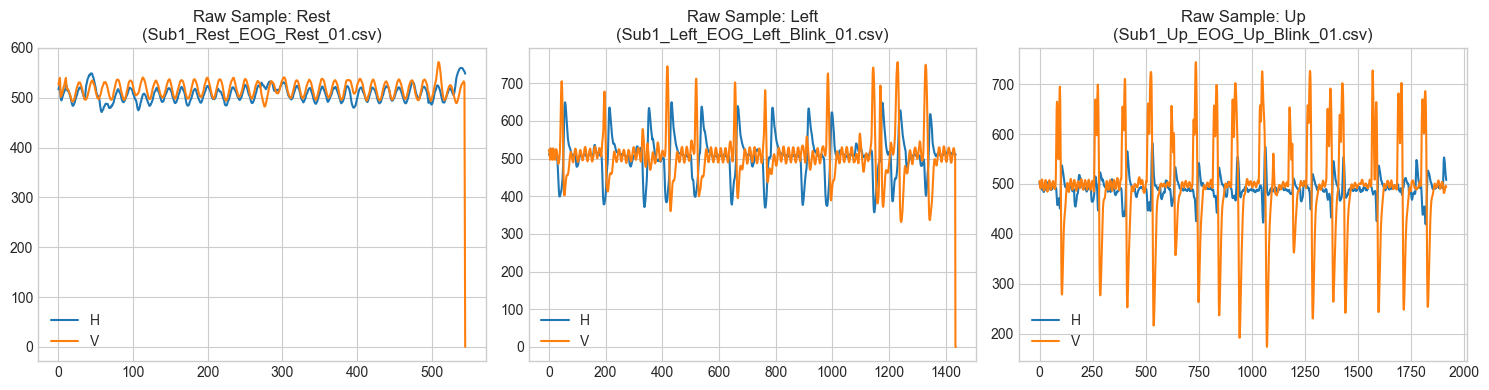

In [4]:
# --- 图 1: 原始数据检查 (Raw Samples) ---
plt.figure(figsize=(15, 4))
for i, cls in enumerate(["Rest", "Left", "Up"]):
    target_idx = CLASSES.index(cls)
    matches = np.where(y_raw_list == target_idx)[0]
    if len(matches) > 0:
        plt.subplot(1, 3, i+1)
        plt.plot(X_raw_list[matches[0]])
        plt.title(f"Raw Sample: {cls}\n({filenames[matches[0]]})")
        plt.legend(['H', 'V'])
plt.tight_layout()
plt.show()

# Module 3: 数据预处理 (Preprocessing & Filtering)

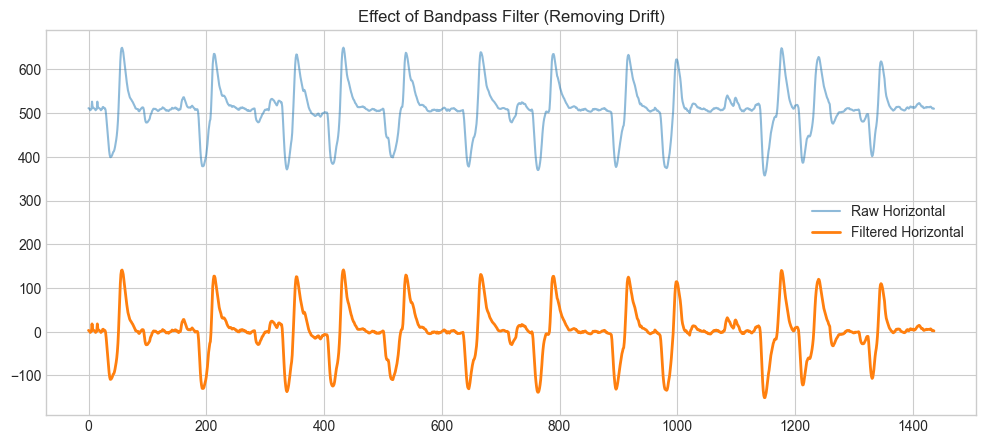

In [5]:
# 修改 Cell 3：不再使用复杂的巴特沃斯
def apply_filter(data):
    # 模拟 ESP32 窗口内的去直流处理
    return data - np.mean(data, axis=0)

X_filtered_list = [apply_filter(d) for d in X_raw_list]
# 可视化滤波效果 (对比)
idx = np.where(y_raw_list == 3)[0][0] # 找一个 Left 的样本
plt.figure(figsize=(12, 5))
plt.plot(X_raw_list[idx][:, 0], label='Raw Horizontal', alpha=0.5)
plt.plot(X_filtered_list[idx][:, 0], label='Filtered Horizontal', linewidth=2)
plt.title("Effect of Bandpass Filter (Removing Drift)")
plt.legend()
plt.show()

# Module 4: 特征工程 (Advanced Feature Extraction)

✂️ Segmenting data...
✅ Created 2092 aligned segments. Shape: (2092, 50, 2)
2. Visualizing data quality...


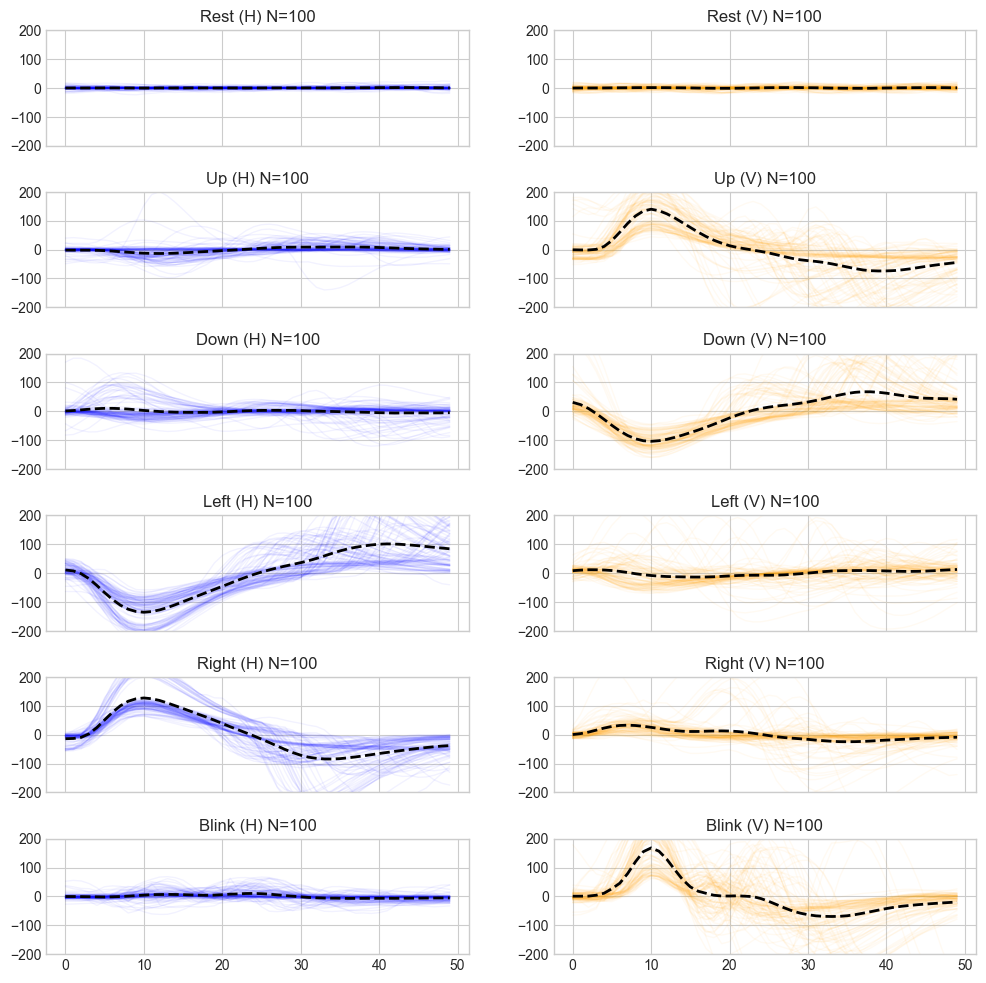

In [8]:
def segment_data_by_peaks_final(data_list, label_list):
    segments = []
    labels = []
    
    PRE_BUFFER = 10    # 峰值前留 10 个点 (200ms)
    HEIGHT_THRES = 60  # 阈值可以稍微调低一点，防止漏掉微弱动作
    DISTANCE = 40      # 峰值间距
    
    for i, data in enumerate(data_list):
        label_idx = label_list[i]
        label_name = CLASSES[label_idx]
        
        # 1. Rest 处理逻辑
        if label_name == "Rest":
            # 步长设大一点，减少样本量，防止类别极其不平衡
            for start in range(0, len(data) - WINDOW_SIZE, WINDOW_SIZE * 2): 
                window = data[start:start+WINDOW_SIZE]
                # 局部去直流：与硬件逻辑对齐
                window = window - np.mean(window, axis=0)
                
                ptp = np.max(window) - np.min(window)
                if ptp < 40: # Rest 必须非常安静
                    segments.append(window)
                    labels.append(label_idx)
            continue

        # 2. Action 处理逻辑：根据你的硬件观察修正极性
        target_peaks = []
        
        # 🌟 重点修改区：极性校对
        if label_name == "Left":
            # 根据你说“左看先向下”，所以找负峰值
            p, _ = find_peaks(-data[:, 0], height=HEIGHT_THRES, distance=DISTANCE)
            target_peaks = p
        elif label_name == "Right":
            # 右看找正峰值
            p, _ = find_peaks(data[:, 0], height=HEIGHT_THRES, distance=DISTANCE)
            target_peaks = p
        elif label_name == "Up":
            p, _ = find_peaks(data[:, 1], height=HEIGHT_THRES, distance=DISTANCE)
            target_peaks = p
        elif label_name == "Down":
            p, _ = find_peaks(-data[:, 1], height=HEIGHT_THRES, distance=DISTANCE)
            target_peaks = p
        elif label_name == "Blink":
            p, _ = find_peaks(data[:, 1], height=HEIGHT_THRES, distance=DISTANCE)
            target_peaks = p

        # 3. 执行切分
        for peak_idx in target_peaks:
            start_idx = peak_idx - PRE_BUFFER
            end_idx = start_idx + WINDOW_SIZE
            
            if start_idx < 0 or end_idx > len(data): continue
                
            window = data[start_idx : end_idx]
            # 🌟 关键：局部去直流
            window = window - np.mean(window, axis=0)
            
            segments.append(window)
            labels.append(label_idx)

    return np.array(segments), np.array(labels)

    # 执行切分
print("✂️ Segmenting data...")
X_segments, y_segments = segment_data_by_peaks_final(X_filtered_list, y_raw_list)
print(f"✅ Created {len(X_segments)} aligned segments. Shape: {X_segments.shape}")

# === 第二步：画图检查 (Data Inspector) ===
print("2. Visualizing data quality...")
import matplotlib.pyplot as plt

def inspect_data_quality(X_segments, y_labels, class_names, num_samples=100):
    unique_labels = np.unique(y_labels)
    n_classes = len(unique_labels)
    
    fig, axes = plt.subplots(n_classes, 2, figsize=(12, 2 * n_classes), sharex=True)
    plt.subplots_adjust(hspace=0.4)
    
    for idx, label_id in enumerate(unique_labels):
        indices = np.where(y_labels == label_id)[0]
        if len(indices) > num_samples:
            indices = np.random.choice(indices, num_samples, replace=False)
            
        current_data = X_segments[indices]
        class_name = class_names[label_id] if label_id < len(class_names) else str(label_id)
        
        # Horizontal
        ax_h = axes[idx, 0]
        ax_h.plot(current_data[:, :, 0].T, color='blue', alpha=0.05, linewidth=1) 
        ax_h.plot(np.mean(current_data[:, :, 0], axis=0), color='black', linewidth=2, linestyle='--')
        ax_h.set_title(f"{class_name} (H) N={len(indices)}")
        ax_h.set_ylim(-200, 200)

        # Vertical
        ax_v = axes[idx, 1]
        ax_v.plot(current_data[:, :, 1].T, color='orange', alpha=0.05, linewidth=1)
        ax_v.plot(np.mean(current_data[:, :, 1], axis=0), color='black', linewidth=2, linestyle='--')
        ax_v.set_title(f"{class_name} (V) N={len(indices)}")
        ax_v.set_ylim(-200, 200)
    plt.show()

# 调用画图
my_classes = ["Rest", "Up", "Down", "Left", "Right", "Blink"]
inspect_data_quality(X_segments, y_segments, my_classes)


In [9]:
def extract_features(segments):
    X_feat = []
    
    for window in segments:
        row_features = []
        for axis in range(2): # 0=H, 1=V
            sig = window[:, axis]
            
            # 【核心关键】去直流：让波形围绕0震荡，区分正负方向
            sig = sig - np.mean(sig)
            
            # 1. 幅度特征
            row_features.append(np.std(sig))               # Std
            row_features.append(np.max(sig) - np.min(sig)) # P2P
            
            # 2. 方向特征 (区分 Left/Right, Up/Down)
            row_features.append(np.mean(sig))              # Mean (接近0)
            row_features.append(np.max(sig))               # Max (正峰值)
            row_features.append(np.min(sig))               # Min (负峰值)
            
            # 3. 速度特征
            diff = np.diff(sig)
            row_features.append(np.mean(np.abs(diff)))
            row_features.append(np.max(np.abs(diff)))
            
        X_feat.append(row_features)
        
    return np.array(X_feat)

print("🔍 Extracting features...")
X_features = extract_features(X_segments)
y_labels = y_segments # 标签直接复用
print(f"✅ Feature Matrix: {X_features.shape}")

🔍 Extracting features...
✅ Feature Matrix: (2092, 14)


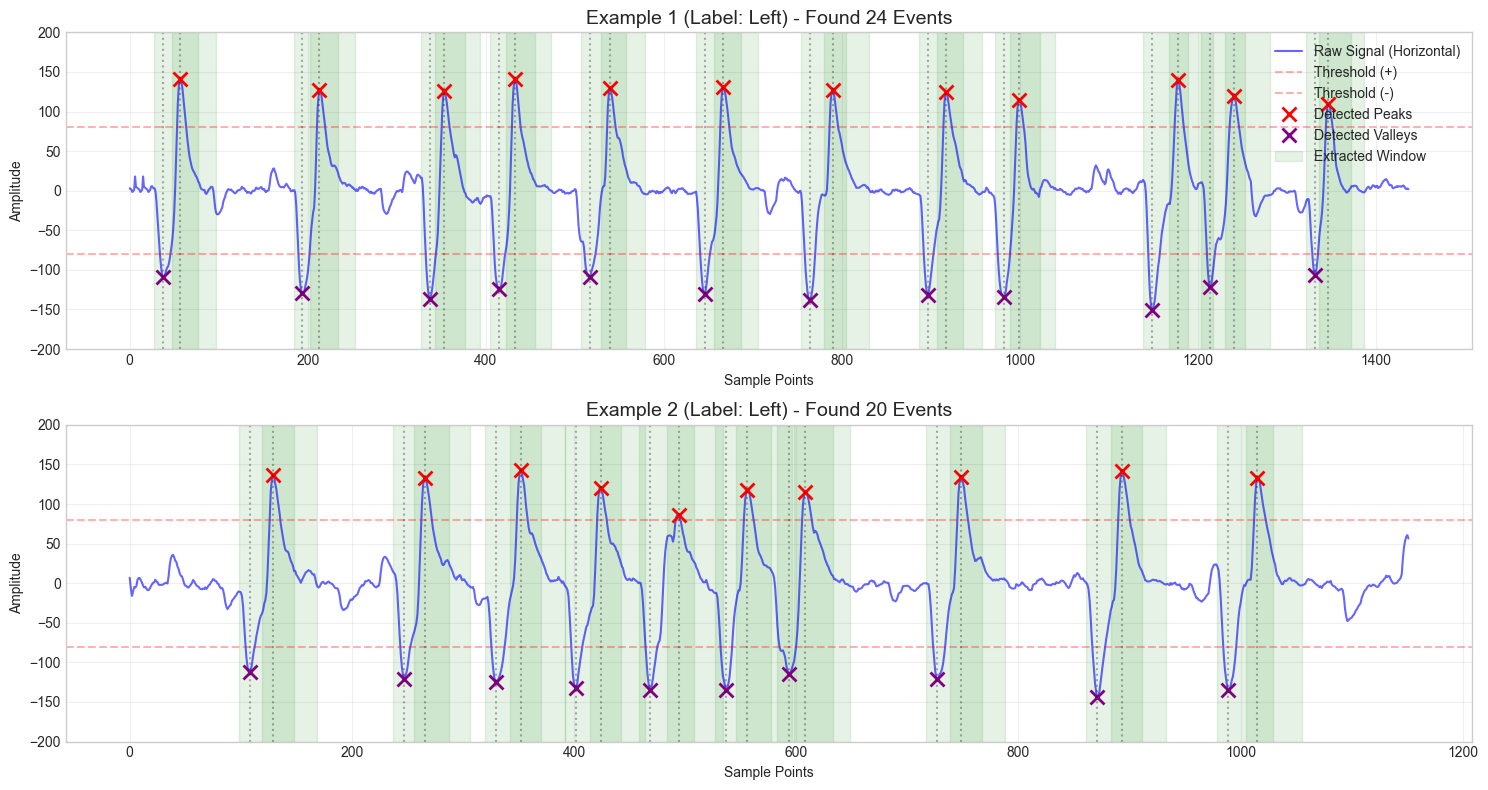

In [10]:

import matplotlib.pyplot as plt
import numpy as np
from scipy.signal import find_peaks

def visualize_peak_detection_process(data_list, label_list, target_label_name="Left", num_examples=3):
    """
    可视化峰值检测过程：画出长波形，标记峰值，画出切分窗口。
    """
    # 找到目标类别的索引
    target_idx = CLASSES.index(target_label_name)
    
    # 筛选出该类别的所有数据
    indices = [i for i, x in enumerate(label_list) if x == target_idx]
    
    if len(indices) == 0:
        print(f"没有找到 {target_label_name} 的数据！")
        return

    # 随机选几个文件展示
    chosen_indices = indices[:num_examples]
    
    # 参数设置 (必须与 segment_data_by_peaks 保持一致)
    HEIGHT_THRES = 80
    DISTANCE = 40
    PRE_BUFFER = 10
    WINDOW_SIZE = 50
    
    plt.figure(figsize=(15, 4 * len(chosen_indices)))
    
    for i, idx in enumerate(chosen_indices):
        data = data_list[idx]
        
        # 假设 Left 主要看 Horizontal (data[:, 0])
        # 如果是 Up/Down/Blink，你可能需要改看 Vertical (data[:, 1])
        # 为了通用，我们这里只画 Horizontal 通道演示
        signal = data[:, 0] 
        
        # 1. 找正峰值 (模拟代码逻辑)
        peaks, _ = find_peaks(signal, height=HEIGHT_THRES, distance=DISTANCE)
        
        # 2. 找负峰值 (模拟代码逻辑)
        valleys, _ = find_peaks(-signal, height=HEIGHT_THRES, distance=DISTANCE)
        
        # 合并
        all_peaks = np.concatenate([peaks, valleys])
        all_peaks = np.sort(all_peaks)
        
        # --- 开始画图 ---
        ax = plt.subplot(len(chosen_indices), 1, i+1)
        ax.plot(signal, label='Raw Signal (Horizontal)', color='blue', alpha=0.6)
        
        # 画阈值线
        ax.axhline(y=HEIGHT_THRES, color='r', linestyle='--', alpha=0.3, label='Threshold (+)')
        ax.axhline(y=-HEIGHT_THRES, color='r', linestyle='--', alpha=0.3, label='Threshold (-)')
        
        # 标记每一个找到的峰值
        ax.plot(peaks, signal[peaks], "x", color='red', markersize=10, markeredgewidth=2, label='Detected Peaks')
        ax.plot(valleys, signal[valleys], "x", color='purple', markersize=10, markeredgewidth=2, label='Detected Valleys')

        # 画出切分窗口 (模拟)
        for p in all_peaks:
            start_x = p - PRE_BUFFER 
            end_x = start_x + WINDOW_SIZE
            
            # 画一个半透明的绿色方块，代表被模型吃掉的窗口
            ax.axvspan(start_x, end_x, color='green', alpha=0.1, label='Extracted Window' if p == all_peaks[0] else "")
            
            # 画一个垂直虚线，代表峰值中心
            ax.axvline(x=p, color='black', linestyle=':', alpha=0.3)
            
        ax.set_title(f"Example {i+1} (Label: {target_label_name}) - Found {len(all_peaks)} Events", fontsize=14)
        ax.set_xlabel("Sample Points")
        ax.set_ylabel("Amplitude")
        if i == 0: ax.legend(loc='upper right')
        ax.grid(True, alpha=0.3)
        ax.set_ylim(-200, 200)

    plt.tight_layout()
    plt.show()

# 🚀 试试看！
# 修改 "Left" 成 "Right" / "Up" / "Down" / "Blink" 来查看不同动作的切分逻辑
visualize_peak_detection_process(X_filtered_list, y_raw_list, target_label_name="Left", num_examples=2)

# Module 5: 模型训练与对比 (Model Comparison)

Training Random Forest...
--> Random Forest Accuracy: 0.8687
Training SVM...
--> SVM Accuracy: 0.8091

🔍 Best Model Report:
              precision    recall  f1-score   support

        Rest       1.00      1.00      1.00        37
          Up       0.87      0.81      0.84        94
        Down       0.79      0.91      0.84        96
        Left       0.89      0.88      0.88        73
       Right       0.90      0.91      0.91        89
       Blink       0.83      0.63      0.72        30

    accuracy                           0.87       419
   macro avg       0.88      0.86      0.86       419
weighted avg       0.87      0.87      0.87       419



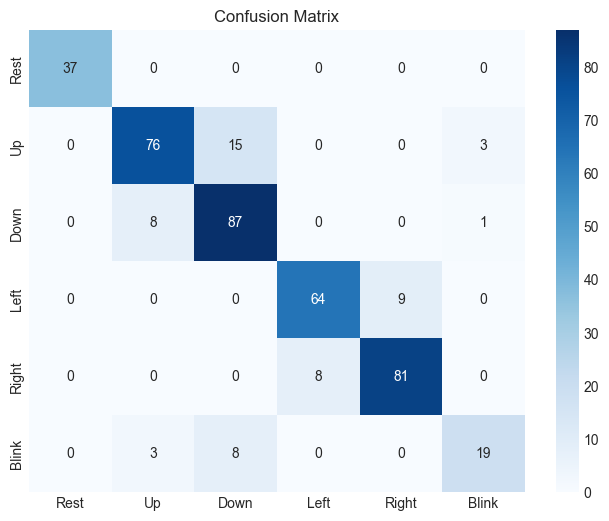

In [15]:
# 1. 数据划分
X_train, X_test, y_train, y_test = train_test_split(X_features, y_labels, test_size=0.2, random_state=42, stratify=y_labels)

# 2. 【核心关键】归一化 (Standardization)
# 训练集 fit_transform, 测试集 transform
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# 3. 定义模型
models = {
    "Random Forest": RandomForestClassifier(n_estimators=15,max_depth=8, random_state=42),
    "SVM": SVC(kernel='rbf', probability=True, random_state=42)
}

# 4. 训练与评估
best_model = None
best_acc = 0

for name, model in models.items():
    print(f"Training {name}...")
    # 注意：所有模型都使用 SCALED 数据训练！
    model.fit(X_train_scaled, y_train)
    
    y_pred = model.predict(X_test_scaled)
    acc = accuracy_score(y_test, y_pred)
    
    print(f"--> {name} Accuracy: {acc:.4f}")
    
    if acc > best_acc:
        best_acc = acc
        best_model = model

# 5. 混淆矩阵 (查看 Rest 是否还有误判)
print("\n🔍 Best Model Report:")
y_pred_final = best_model.predict(X_test_scaled)
print(classification_report(y_test, y_pred_final, target_names=CLASSES))

plt.figure(figsize=(8, 6))
sns.heatmap(confusion_matrix(y_test, y_pred_final), annot=True, fmt='d', cmap='Blues', xticklabels=CLASSES, yticklabels=CLASSES)
plt.title("Confusion Matrix")
plt.show()

# Module 6: 深度评估与误触分析 (Evaluation)

# Module 7: 保存最佳模型

In [18]:
# 保存模型和 Scaler
# 这一步非常重要，实时代码需要这两个文件
print(f"💾 Saving best model ({best_acc:.2%})...")
joblib.dump(best_model, 'eog_model_esp32_multi.joblib')
joblib.dump(scaler, 'eog_scaler_esp32_multi.joblib')
print("✅ Saved 'eog_model_esp32_multi.joblib' and 'eog_scaler_esp32_multi.joblib' successfully!")

💾 Saving best model (86.87%)...
✅ Saved 'eog_model_esp32_multi.joblib' and 'eog_scaler_esp32_multi.joblib' successfully!


# 静态检测

⏳ Loading model...

🔍 Analyzing: Real_Test_Left.csv


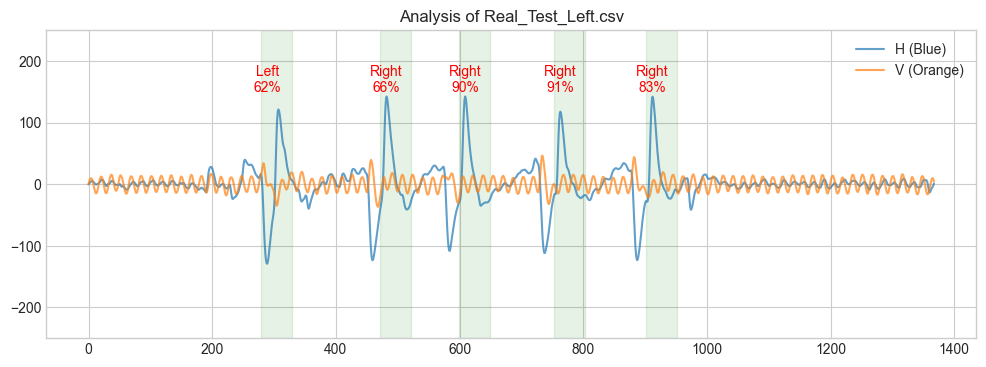


🔍 Analyzing: Real_Test_Right.csv


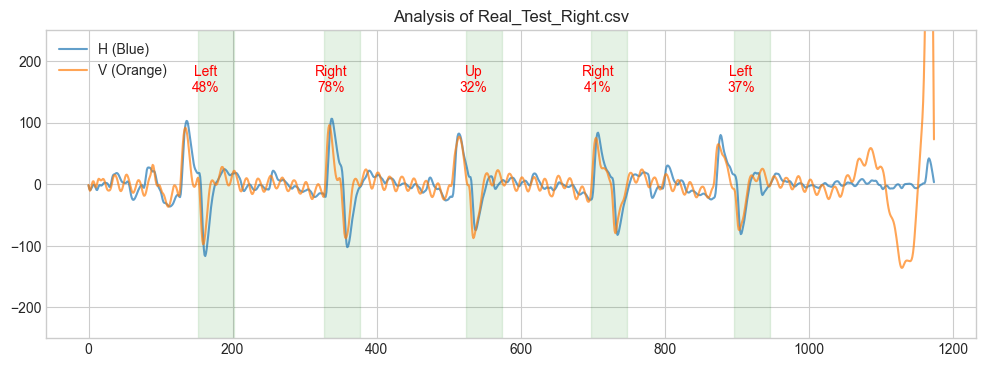


🔍 Analyzing: Real_Test_Up.csv


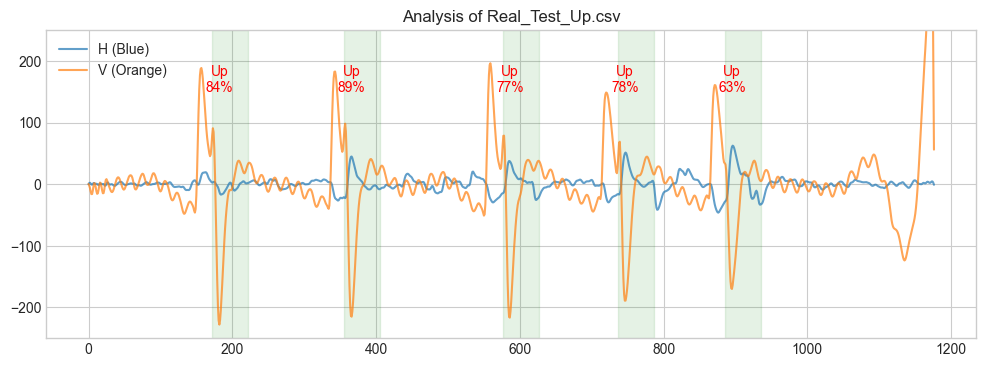


🔍 Analyzing: Real_Test_Down.csv


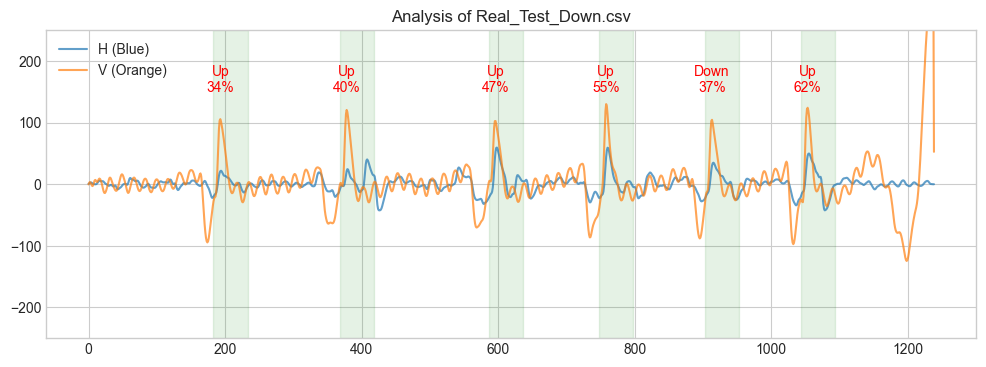


🔍 Analyzing: Real_Test_Blink.csv


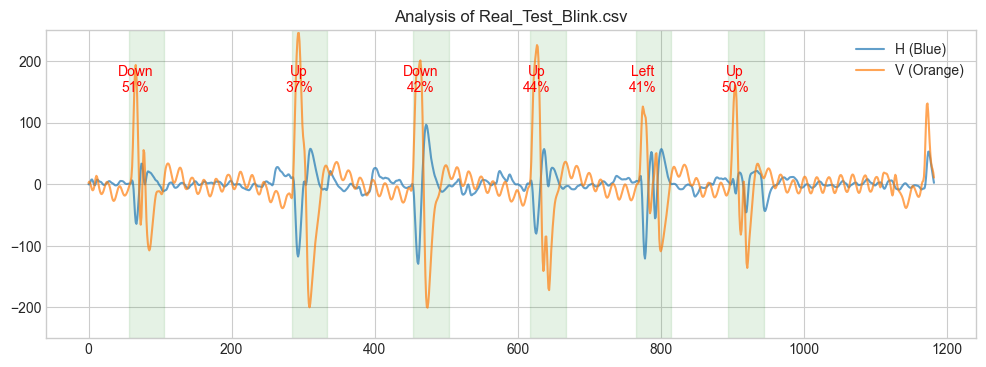

In [19]:
import joblib
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy import signal
from scipy.signal import find_peaks
import os

# ==== 1. 配置区域 ====
# ⚠️ 把这里改成你刚刚录制的真实文件路径
TEST_FILES = [
    "EOG_data/Real_Test/Real_Test_Left.csv",
    "EOG_data/Real_Test/Real_Test_Right.csv",
    "EOG_data/Real_Test/Real_Test_Up.csv",
    "EOG_data/Real_Test/Real_Test_Down.csv",
    "EOG_data/Real_Test/Real_Test_Blink.csv",
    # ... 把你录的文件都放这里
]

MODEL_PATH = 'eog_model_esp32_multi.joblib'
SCALER_PATH = 'eog_scaler_esp32_multi.joblib'
CLASSES = ["Rest", "Up", "Down", "Left", "Right", "Blink"]

# ==== 2. 加载模型 ====
print("⏳ Loading model...")
clf = joblib.load(MODEL_PATH)
scaler = joblib.load(SCALER_PATH)

# ==== 3. 辅助函数 ====
def simple_process(filepath):
    """读取 -> 滤波 -> 盲测切分"""
    # A. 读取
    try:
        df = pd.read_csv(filepath, header=0, usecols=['data 0', 'data 1']) # 假设是这两列
    except:
        # 兼容 OpenBCI GUI 格式或不带表头的格式，根据实际情况调整
        df = pd.read_csv(filepath, header=None).iloc[:, [1, 2]] 
        
    raw_data = df.values
    
    # B. 滤波 (0.5-10Hz)
    b, a = signal.butter(4, [0.5/25, 10.0/25], btype='band')
    filtered_data = signal.filtfilt(b, a, raw_data, axis=0)
    
    # C. 盲测切分 (找幅度>80的动作)
    segments = []
    timestamps = []
    
    # 取绝对值找峰
    energy = np.max(np.abs(filtered_data), axis=1)
    peaks, _ = find_peaks(energy, height=80, distance=50)
    
    for p in peaks:
        start = p - 10
        end = start + 50
        if start < 0 or end > len(filtered_data): continue
        segments.append(filtered_data[start:end])
        timestamps.append(p)
        
    return np.array(segments), timestamps, filtered_data

# ==== 4. 批量验证 & 画图 ====
for fpath in TEST_FILES:
    if not os.path.exists(fpath):
        print(f"⚠️ 文件不存在: {fpath} (跳过)")
        continue
        
    print(f"\n🔍 Analyzing: {os.path.basename(fpath)}")
    X_seg, time_pts, full_wave = simple_process(fpath)
    
    if len(X_seg) == 0:
        print("❌ 未检测到大幅度动作 (可能是阈值太高或动作太轻)")
        continue
        
    # 特征提取 & 预测
    X_feats = []
    for w in X_seg:
        feats = []
        for axis in range(2):
            sig = w[:, axis]
            sig = sig - np.mean(sig) # 去直流
            feats.append(np.std(sig))
            feats.append(np.max(sig) - np.min(sig))
            feats.append(np.mean(sig))
            feats.append(np.max(sig))
            feats.append(np.min(sig))
            diff = np.diff(sig)
            feats.append(np.mean(np.abs(diff)))
            feats.append(np.max(np.abs(diff)))
        X_feats.append(feats)
        
    # 预测
    preds = clf.predict(scaler.transform(X_feats))
    probs = clf.predict_proba(scaler.transform(X_feats))
    
    # ==== 画图展示结果 ====
    plt.figure(figsize=(12, 4))
    plt.plot(full_wave[:, 0], label='H (Blue)', alpha=0.7)
    plt.plot(full_wave[:, 1], label='V (Orange)', alpha=0.7)
    
    # 在图上标记模型预测的结果
    for i, t in enumerate(time_pts):
        label = CLASSES[preds[i]]
        conf = np.max(probs[i])
        
        # 你的"修正补丁"逻辑可以在脑子里运行：
        # 如果你录的是 Left 文件，但这里显示 Right，那你就知道实时代码里要加个 if 改过来
        
        plt.axvspan(t-10, t+40, color='green', alpha=0.1)
        plt.text(t, 150, f"{label}\n{conf:.0%}", color='red', fontsize=10, ha='center')
        
    plt.title(f"Analysis of {os.path.basename(fpath)}")
    plt.legend()
    plt.ylim(-250, 250)
    plt.show()

# 模型导出给esp32的header file

In [20]:

import joblib
from micromlgen import port

# 1. 载入你训练好的模型和 Scaler
MODEL_PATH = 'eog_model_esp32_multi.joblib'
SCALER_PATH = 'eog_scaler_esp32_multi.joblib'

print("⏳ 正在加载模型和 Scaler...")
model = joblib.load(MODEL_PATH)
scaler = joblib.load(SCALER_PATH)

# 2. 转换机器学习模型为 C++
print("⚙️ 正在转换 Random Forest 模型...")
c_code_model = port(model)

# 3. 提取 Scaler 的参数 (均值和缩放比例)
mean_array = scaler.mean_
scale_array = scaler.scale_

# 将 Python 数组格式化为 C++ 数组字符串
mean_str = ", ".join([str(x) for x in mean_array])
scale_str = ", ".join([str(x) for x in scale_array])

c_code_scaler = f"""
// ==========================================
// 自动生成的 StandardScaler 参数
// ==========================================
const float scaler_mean[14] = {{{mean_str}}};
const float scaler_scale[14] = {{{scale_str}}};

// 标准化特征的辅助函数
void scale_features(float* raw_features, float* scaled_features) {{
    for(int i = 0; i < 14; i++) {{
        scaled_features[i] = (raw_features[i] - scaler_mean[i]) / scaler_scale[i];
    }}
}}
"""

# 4. 合并并保存为一个终极的头文件
with open("EOG_AI_Engine_esp32_multi.h", "w") as f:
    f.write(c_code_scaler)
    f.write("\n\n")
    f.write(c_code_model)

print("✅ 大功告成！已生成 EOG_AI_Engine_esp32_multi.h，请把它拖进 Arduino 项目文件夹中！")

⏳ 正在加载模型和 Scaler...
⚙️ 正在转换 Random Forest 模型...
✅ 大功告成！已生成 EOG_AI_Engine_esp32_multi.h，请把它拖进 Arduino 项目文件夹中！
